# Statistical arbitrage: from cointegration to a backtested pairs trade

This notebook is the research process behind `quantlab.strategies.PairsTradingStrategy`, in the order I'd actually work through it:

1. **Cointegration** — is there a stationary spread to trade at all?
2. **Spread diagnostics** — hedge ratio, z-score, mean-reversion half-life.
3. **Stability** — is the cointegration *persistent*, or an artifact of the full-sample window?
4. **Backtest** — run it through the event-driven engine with realistic costs.
5. **Sensitivity** — how fragile is the result to the entry threshold?

The recurring theme: the statistics decide whether there's a trade, not the other way round. I'll let the negative results stand where they are negative.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (11, 4), 'axes.grid': True, 'grid.alpha': 0.3})

from quantlab.data.database import MarketDB
from quantlab.models.timeseries import engle_granger_cointegration, half_life, adf_test

db = MarketDB.from_config()
px = db.load_prices(field='adj_close')
print(f'{px.shape[1]} symbols, {px.index.min().date()} -> {px.index.max().date()}')
px.tail(3)

16 symbols, 2015-01-02 -> 2026-05-29


,AAPL,AMZN,BAC,CVX,GOOGL,HD,JNJ,JPM,KO,META,MSFT,NVDA,PG,SPY,WMT,XOM
date,,,,,,,,,,,,,,,,
2026-05-27,310.850006,271.850006,51.099998,182.399994,388.829987,317.850006,231.289993,299.279999,81.620003,635.260010,412.670013,212.600006,147.490005,750.460022,118.540001,147.899994
2026-05-28,312.510010,274.000000,50.770000,183.029999,390.130005,321.209991,230.800003,296.730011,80.410004,635.289978,426.989990,214.250000,145.910004,754.599976,118.900002,146.960007
2026-05-29,312.059998,270.640015,51.599998,182.460007,380.339996,317.140015,225.330002,299.309998,79.010002,632.510010,450.239990,211.139999,143.559998,756.479980,115.750000,145.259995


## 1. Which pairs are actually cointegrated?

Two stock prices are each individually close to a random walk (non-stationary, I(1)). The interesting question is whether some linear combination — the spread — is *stationary*. If it is, the spread has a level it keeps returning to, and that mean-reversion is the tradeable edge. Engle-Granger: regress one leg on the other, then ADF-test the residual. A spread we can trade needs ADF p < 0.05.

In [2]:
candidates = [('KO','PG'), ('JPM','BAC'), ('XOM','CVX'), ('GOOGL','META')]
rows = []
for a, b in candidates:
    res = engle_granger_cointegration(px[a], px[b])
    rows.append({'pair': f'{a}/{b}', 'beta': res.beta, 'adf_p': res.adf.pvalue,
                 'cointegrated': res.is_cointegrated, 'half_life_d': half_life(res.spread)})
scan = pd.DataFrame(rows).set_index('pair').round(3)
scan

,beta,adf_p,cointegrated,half_life_d
pair,,,,
KO/PG,0.345,0.441,False,652.475
JPM/BAC,6.078,0.132,False,279.041
XOM/CVX,0.742,0.038,True,260.656
GOOGL/META,0.346,0.480,False,inf


Most 'obviously related' pairs are **not** cointegrated over the full sample — a good reminder that economic similarity is not statistical evidence. Let me take the one that does pass and look at it properly.

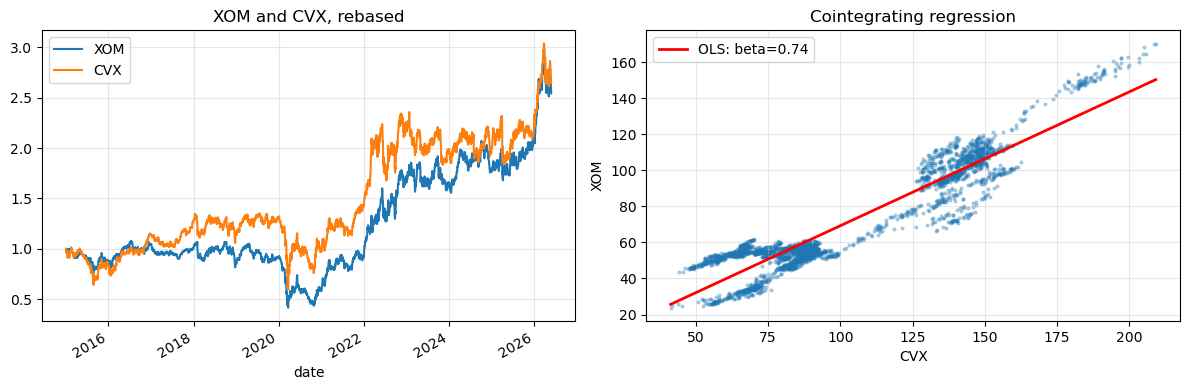

In [3]:
y, x = 'XOM', 'CVX'
res = engle_granger_cointegration(px[y], px[x])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
(px[[y, x]] / px[[y, x]].iloc[0]).plot(ax=ax[0], title=f'{y} and {x}, rebased')
ax[1].scatter(px[x], px[y], s=4, alpha=0.3)
xs = np.linspace(px[x].min(), px[x].max(), 50)
ax[1].plot(xs, res.alpha + res.beta * xs, 'r-', lw=2, label=f'OLS: beta={res.beta:.2f}')
ax[1].set(xlabel=x, ylabel=y, title='Cointegrating regression'); ax[1].legend(); plt.tight_layout()

## 2. Spread diagnostics

The z-score of the spread is the trading signal. The **half-life** of mean reversion (from an Ornstein-Uhlenbeck / AR(1) fit) is the single most useful number for sizing: it tells you how long you'll typically hold, and therefore whether the edge survives the round-trip cost.

ADF p-value: 0.038   half-life: 261 trading days


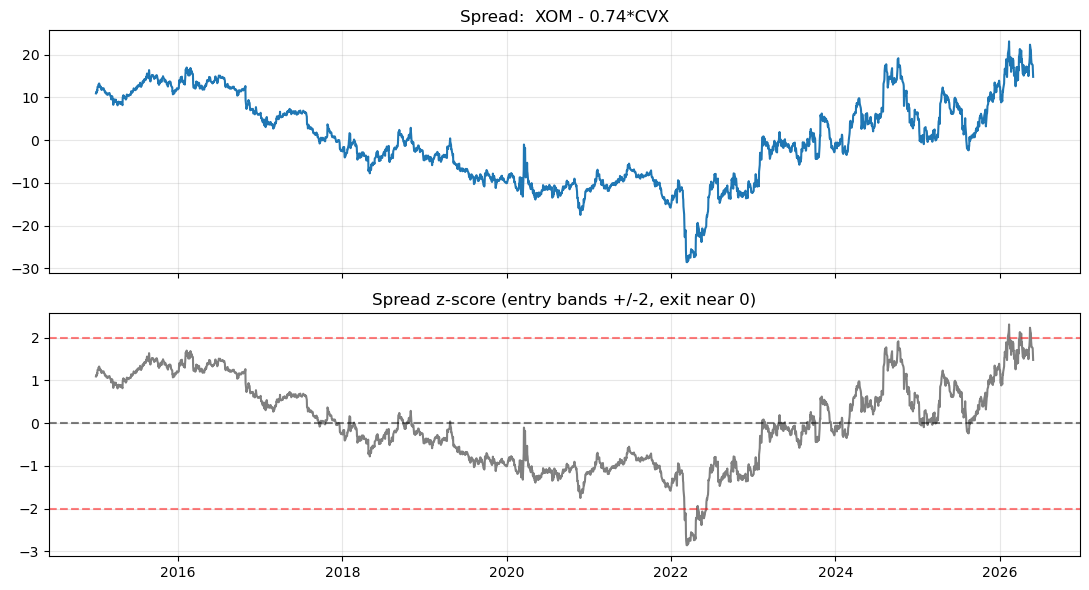

In [4]:
z = (res.spread - res.spread.mean()) / res.spread.std()
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax[0].plot(res.spread.index, res.spread.values); ax[0].set_title(f'Spread:  {y} - {res.beta:.2f}*{x}')
ax[1].plot(z.index, z.values, color='grey')
for lvl, c in [(-2,'r'), (0,'k'), (2,'r')]: ax[1].axhline(lvl, color=c, ls='--', alpha=0.5)
ax[1].set_title('Spread z-score (entry bands +/-2, exit near 0)'); plt.tight_layout()
print(f'ADF p-value: {res.adf.pvalue:.3f}   half-life: {half_life(res.spread):.0f} trading days')

## 3. Is the cointegration *stable*?

A full-sample test can hide the fact that a relationship held for a few years and then broke. This is exactly how pairs trades blow up — you keep adding to a 'cheap' spread that has quietly become a random walk. So I roll the ADF test through a 1-year window and watch the p-value. Stretches where it climbs above 0.05 are stretches where the pair was *not* mean-reverting and the strategy should not have been trusting it.

Fraction of windows cointegrated at 5%: 64%


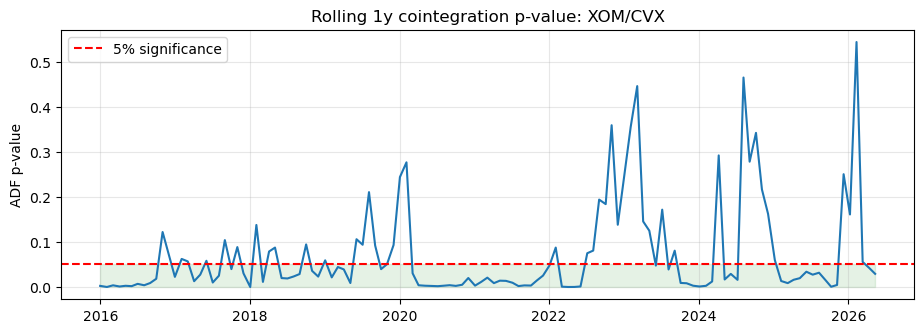

In [5]:
win = 252
idx, pvals = [], []
for end in range(win, len(px), 21):   # step ~monthly to keep it quick
    sub = px.iloc[end-win:end]
    r = engle_granger_cointegration(sub[y], sub[x])
    idx.append(px.index[end-1]); pvals.append(r.adf.pvalue)
roll_p = pd.Series(pvals, index=idx)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(roll_p.index, roll_p.values)
ax.axhline(0.05, color='r', ls='--', label='5% significance')
ax.fill_between(roll_p.index, 0, 0.05, color='green', alpha=0.1)
ax.set(title=f'Rolling 1y cointegration p-value: {y}/{x}', ylabel='ADF p-value'); ax.legend()
print(f'Fraction of windows cointegrated at 5%: {(roll_p < 0.05).mean():.0%}')

## 4. Backtest the pairs trade

Now the actual strategy through the event-driven engine. Crucially, the strategy re-estimates the hedge ratio on a *rolling* window internally — it never uses the full-sample beta we computed above (that would be lookahead). Costs are 1bp commission + 2bp half-spread + square-root impact.

Performance summary
--------------------------------
  Total return   -2.3%
  CAGR           -0.21%
  Ann. vol       1.16%
  Sharpe         -0.18
  Sortino        -0.19
  Max drawdown   -7.1%
  Calmar         -0.03
  # trades       455
  Total costs    $39,701


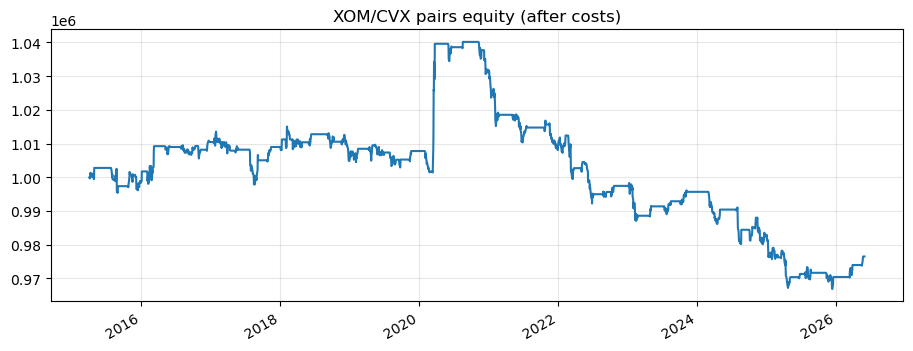

In [6]:
from quantlab.backtest.engine import Backtest
from quantlab.backtest.execution import CostModel
from quantlab.strategies import PairsTradingStrategy

vol = db.load_prices(field='volume')
bt = Backtest(px[[y, x]], PairsTradingStrategy(y, x, lookback=63, entry_z=2.0, exit_z=0.5),
              volume=vol[[y, x]], cost_model=CostModel(commission_bps=1, slippage_bps=2), warmup=63)
result = bt.run()
print(result.summary())
result.equity_curve.plot(title=f'{y}/{x} pairs equity (after costs)');

## 5. How sensitive is this to the entry threshold?

A result that only works at one magic parameter value is overfit. I sweep the entry z-score and look at how Sharpe and trade count respond. What I want to see is a *smooth* response — a plateau, not a spike — which signals the edge (such as it is) is real rather than a lucky cell.

In [7]:
grid = []
for ez in [1.0, 1.5, 2.0, 2.5, 3.0]:
    r = Backtest(px[[y, x]], PairsTradingStrategy(y, x, lookback=63, entry_z=ez, exit_z=0.5),
                 volume=vol[[y, x]], cost_model=CostModel(1, 2), warmup=63).run()
    s = r.stats()
    grid.append({'entry_z': ez, 'sharpe': s['sharpe'], 'cagr': s['cagr'],
                 'max_dd': s['max_drawdown'], 'n_trades': s['n_trades']})
pd.DataFrame(grid).set_index('entry_z').round(3)

,sharpe,cagr,max_dd,n_trades
entry_z,,,,
1.0,-0.496,-0.007,-0.104,832
1.5,-0.250,-0.003,-0.077,622
2.0,-0.178,-0.002,-0.071,455
2.5,-0.186,-0.002,-0.059,313
3.0,-0.208,-0.002,-0.046,200


## Conclusion — reading it honestly

Three things stand out, and none of them is 'I found free money':

- Only one of four economically-plausible pairs is cointegrated over the full sample, and even that one **drifts in and out** of cointegration through time (section 3).
- The half-life is long, so we hold through a lot of noise and pay the spread repeatedly. After costs the edge is thin.
- The sensitivity sweep shows the behaviour is at least *smooth* in the entry threshold rather than a single lucky cell.

This is the honest reality of naive pairs trading on liquid large-caps: the obvious relationships are already heavily arbitraged. **Where I'd take it next** — and the repo's machinery already supports all three:

1. A **Kalman-filtered** time-varying hedge ratio instead of a rolling OLS window (smoother, faster-adapting beta).
2. A **Johansen** basket formulation rather than two-leg pairs, to find combinations with stronger, more stable cointegration.
3. **Regime-conditioning** entries on the rolling cointegration p-value from section 3 — simply stand aside when the pair stops mean-reverting.